In [1]:
!uv pip install SimpleITK monai

Using Python 3.12.13 environment at: /usr
Resolved 32 packages in 406ms
Prepared 2 packages in 1.82s
Installed 2 packages in 40ms
 + monai==1.5.2
 + simpleitk==2.5.5


In [2]:
import warnings
# Suppress specific indexing, CUDA, and MONAI deprecation warnings
warnings.filterwarnings("ignore", category=UserWarning, message=".*non-tuple sequence for multidimensional indexing.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*cuda.cudart module is deprecated.*")
warnings.filterwarnings("ignore", category=FutureWarning, message=".*monai.transforms.*")

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Load MSSEG dataset

In [5]:
import os
import glob
import zipfile
import random
from pathlib import Path

# MSSEG loader for 3 modalities:
# channel 0 = FLAIR, channel 1 = T1, channel 2 = T2

SEED = 42
random.seed(SEED)

# ---- Paths: MSSEG ONLY ----
MSSEG_TRAIN_ZIP = "/content/drive/MyDrive/MSSEG-Training.zip"
MSSEG_TEST_ZIP = "/content/drive/MyDrive/MSSEG-Testing.zip"
MSSEG_EXTRACT_DIR = "/content/MSSEG-Training"
MSSEG_EXTRACT_DIR_TEST = "/content/MSSEG-Testing"

def unzip_if_needed(zip_path, extract_dir):
    """Extract a zip once and return the extracted directory."""
    if zip_path and os.path.exists(zip_path):
        marker = Path(extract_dir) / ".extracted"
        if not marker.exists():
            os.makedirs(extract_dir, exist_ok=True)
            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)
            marker.touch()
        return extract_dir
    return extract_dir

def first_match(files, include_terms, exclude_terms=()):
    """Pick the first file containing all include_terms and none of exclude_terms."""
    include_terms = [t.upper() for t in include_terms]
    exclude_terms = [t.upper() for t in exclude_terms]
    candidates = []
    for f in files:
        name = os.path.basename(f).upper()
        if all(t in name for t in include_terms) and not any(t in name for t in exclude_terms):
            candidates.append(f)
    return sorted(candidates)[0] if candidates else None

def find_case_files(case_dir):
    """Find FLAIR, T1, T2, and lesion mask inside one subject/case folder."""
    nii_files = glob.glob(os.path.join(case_dir, "**", "*.nii*"), recursive=True)
    if not nii_files:
        return None

    flair = first_match(nii_files, ["FLAIR"])
    t2 = first_match(nii_files, ["T2"], exclude_terms=["T2STAR", "T2_STAR"])
    t1 = first_match(nii_files, ["T1"], exclude_terms=["GADO", "GD", "GAD", "CE", "CONTRAST"])

    label = (
        first_match(nii_files, ["CONSENSUS"])
        or first_match(nii_files, ["LESION"])
        or first_match(nii_files, ["MASK"])
        or first_match(nii_files, ["SEG"])
        or first_match(nii_files, ["GT"])
    )

    image_set = {p for p in [flair, t1, t2] if p}
    if label in image_set:
        label = None

    if flair and t1 and t2 and label:
        return {"flair": flair, "t1": t1, "t2": t2, "label": label}
    return None

def collect_dataset(root_dir, source_name):
    """Recursively collect valid cases with all 3 modalities and a label."""
    root_dir = str(root_dir)
    if not os.path.exists(root_dir):
        print(f"WARNING: {source_name} root not found: {root_dir}")
        return []

    all_dirs = [root_dir] + [p for p, _, _ in os.walk(root_dir)]
    cases = []
    seen = set()
    for d in all_dirs:
        item = find_case_files(d)
        if item is None:
            continue
        key = tuple(item[k] for k in ["flair", "t1", "t2", "label"])
        if key in seen:
            continue
        seen.add(key)
        item["source"] = source_name
        item["case_id"] = f"{source_name}_{len(cases):03d}"
        cases.append(item)
    return cases

msseg_root = unzip_if_needed(MSSEG_TRAIN_ZIP, MSSEG_EXTRACT_DIR)
msseg_test_root = unzip_if_needed(MSSEG_TEST_ZIP, MSSEG_EXTRACT_DIR_TEST)

msseg_train_files = collect_dataset(msseg_root, "MSSEG")
msseg_test_files = collect_dataset(msseg_test_root, "MSSEG_TEST")

data_dicts = msseg_train_files + msseg_test_files
random.shuffle(data_dicts)

print(f"MSSEG train cases: {len(msseg_train_files)}")
print(f"MSSEG test cases: {len(msseg_test_files)}")
print(f"Total cases available: {len(data_dicts)}")

if data_dicts:
    print("Example case:")
    for k, v in data_dicts[0].items():
        print(f"  {k}: {v}")
else:
    raise RuntimeError("No complete MSSEG cases found. Check paths and filename patterns.")

MSSEG train cases: 15
MSSEG test cases: 38
Total cases available: 53
Example case:
  flair: /content/MSSEG-Training/Training/Center_07/Patient_05/Preprocessed_Data/FLAIR_preprocessed.nii.gz
  t1: /content/MSSEG-Training/Training/Center_07/Patient_05/Raw_Data/T1.nii.gz
  t2: /content/MSSEG-Training/Training/Center_07/Patient_05/Preprocessed_Data/T2_preprocessed.nii.gz
  label: /content/MSSEG-Training/Training/Center_07/Patient_05/Masks/Consensus.nii.gz
  source: MSSEG
  case_id: MSSEG_009


## Data Preprocessing

In [22]:
import os
import torch
import random
from monai.transforms import (
    Compose, # Combines multiple transforms into a chain
    LoadImaged, # Loads medical images from file paths
    EnsureChannelFirstd, # Ensures data is in [C, H, W, D] format
    Orientationd, # Standardizes image orientation (e.g., RAS)
    Spacingd, # Resamples images to a consistent voxel size
    NormalizeIntensityd, # Normalizes intensity values (mean 0, std 1)
    ConcatItemsd, # Concatenates multiple modality images into one tensor
    DeleteItemsd, # Removes temporary dictionary keys to save memory
    RandCropByPosNegLabeld, # Randomly crops patches based on label presence
    EnsureTyped, # Converts data to torch tensors
    CropForegroundd, # Removes unnecessary background padding
    RandFlipd, # Randomly flips images for augmentation
    RandRotate90d, # Randomly rotates images by 90 degrees
    RandScaleIntensityd, # Randomly scales intensity values
    RandShiftIntensityd, # Randomly shifts intensity values
    RandGaussianNoised, # Adds random Gaussian noise
    RandBiasFieldd, # Simulates MRI bias field artifacts
    Lambdad, # Allows for custom user-defined functions
)
from monai.data import PersistentDataset, DataLoader # Efficient data handling and caching

# Labels must be binary: background=0, lesion=1.
def binarize_label(x):
    return (x > 0).astype(x.dtype) # Converts any non-zero value to 1

base_transforms = [
    LoadImaged(keys=["flair", "t1", "t2", "label"]), # Load 3 modalities + mask
    EnsureChannelFirstd(keys=["flair", "t1", "t2", "label"]), # Add channel dim if missing
    Orientationd(keys=["flair", "t1", "t2", "label"], axcodes="RAS"), # Set to RAS orientation
    Spacingd( # Resample all to 1mm isotropic resolution
        keys=["flair", "t1", "t2", "label"],
        pixdim=(1.0, 1.0, 1.0),
        mode=("bilinear", "bilinear", "bilinear", "nearest"), # Use nearest for masks
        padding_mode="zeros",
    ),
    Lambdad(keys="label", func=binarize_label), # Apply binarization to mask
    CropForegroundd(keys=["flair", "t1", "t2", "label"], source_key="flair"), # Crop based on brain mask
    NormalizeIntensityd(keys=["flair", "t1", "t2"], nonzero=True, channel_wise=True), # Normalize each modality
    ConcatItemsd(keys=["flair", "t1", "t2"], name="image", dim=0), # Stack into [3, D, H, W]
    DeleteItemsd(keys=["flair", "t1", "t2"]), # Clean up original keys
]

train_transforms = Compose(base_transforms + [
    RandCropByPosNegLabeld( # Ensure patches have lesions with high probability
        keys=["image", "label"],
        label_key="label",
        spatial_size=(96, 96, 96), # Size of the 3D training cube
        pos=3, # Ratio of positive (lesion) crops
        neg=1, # Ratio of negative (background) crops
        num_samples=4, # Number of patches per volume
        image_key="image",
        image_threshold=0,
    ),
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=0), # Augmentation: Sagittal flip
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=1), # Augmentation: Coronal flip
    RandFlipd(keys=["image", "label"], prob=0.5, spatial_axis=2), # Augmentation: Axial flip
    RandRotate90d(keys=["image", "label"], prob=0.25, max_k=3), # Augmentation: 90 deg rotation
    RandScaleIntensityd(keys="image", factors=0.15, prob=0.35), # Augmentation: Scale brightness
    RandShiftIntensityd(keys="image", offsets=0.10, prob=0.35), # Augmentation: Shift brightness
    RandGaussianNoised(keys="image", prob=0.15, mean=0.0, std=0.01), # Augmentation: Add noise
    RandBiasFieldd(keys="image", prob=0.15, coeff_range=(0.0, 0.03)), # Augmentation: MRI bias simulation
    EnsureTyped(keys=["image", "label"]), # Ensure final output is tensor
])

val_transforms = Compose(base_transforms + [
    EnsureTyped(keys=["image", "label"]), # No augmentation for validation
])

# Updated to use fixed sets: Train on MSSEG (15), Val on MSSEG_TEST (38)
train_files = msseg_train_files # Assign training list
val_files = msseg_test_files # Assign validation list

cache_dir_train = "/content/persistent_cache_train_combined_3modalities"
cache_dir_val = "/content/persistent_cache_val_combined_3modalities"
os.makedirs(cache_dir_train, exist_ok=True) # Create cache folder for train
os.makedirs(cache_dir_val, exist_ok=True) # Create cache folder for val

train_ds = PersistentDataset(data=train_files, transform=train_transforms, cache_dir=cache_dir_train) # Persistent cache to speed up
val_ds = PersistentDataset(data=val_files, transform=val_transforms, cache_dir=cache_dir_val)

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0) # Data feeder
val_loader = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0)

print(f"Pipeline ready with FIXED split. Train cases: {len(train_files)}, Val cases: {len(val_files)}")

Pipeline ready with FIXED split. Train cases: 15, Val cases: 38


## Data Analysis

In [7]:
import torch
import numpy as np

def explore_dataset(dataloader):
    print("Pulling a sample from the dataset...\n")
    batch = next(iter(dataloader))
    images = batch["image"]
    labels = batch["label"]
    print("1. Shape Information ")
    print(f"Image shape : {images.shape}")
    print(f"Mask shape  : {labels.shape}")
    print(f"Image dtype : {images.dtype}\n")
    print("2. Intensity Statistics ")
    print(f"Max value : {images.max().item():.2f}")
    print(f"Min value : {images.min().item():.2f}\n")
    print("3. Imbalance Analysis ")
    total_voxels = labels.numel()
    lesion_voxels = labels.sum().item()
    imbalance_ratio = (lesion_voxels / total_voxels) * 100
    print(f"Lesion to brain volume ratio: {imbalance_ratio:.4f}%")

explore_dataset(train_loader)

Pulling a sample from the dataset...

1. Shape Information 
Image shape : torch.Size([4, 3, 96, 96, 96])
Mask shape  : torch.Size([4, 1, 96, 96, 96])
Image dtype : torch.float32

2. Intensity Statistics 
Max value : 6.78
Min value : -3.35

3. Imbalance Analysis 
Lesion to brain volume ratio: 0.1239%


Visualizing training sample: MSSEG_000


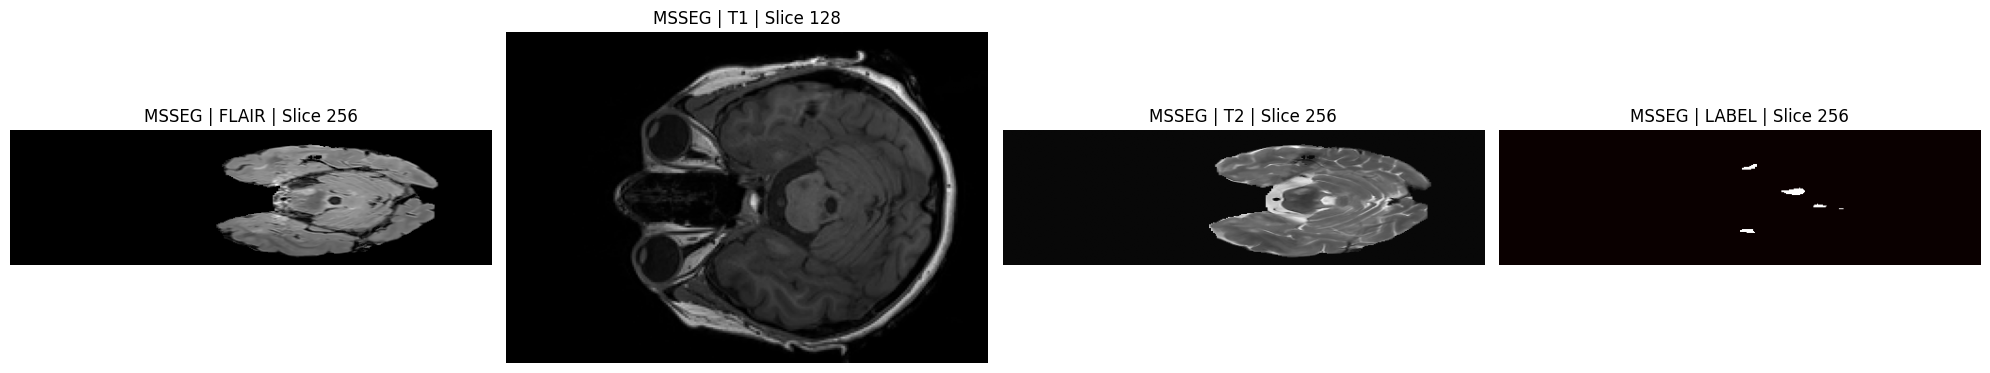

In [8]:
import nibabel as nib
import matplotlib.pyplot as plt
import numpy as np

def visualize_sample(sample_dict, slice_idx=None):
    fig, axes = plt.subplots(1, 4, figsize=(20, 5))
    modalities = ["flair", "t1", "t2", "label"]

    for i, mod in enumerate(modalities):
        img = nib.load(sample_dict[mod]).get_fdata()
        current_slice = img.shape[2] // 2 if slice_idx is None else slice_idx
        cmap = "hot" if mod == "label" else "gray"
        axes[i].imshow(img[:, :, current_slice], cmap=cmap)
        axes[i].set_title(f"{sample_dict.get('source', 'case')} | {mod.upper()} | Slice {current_slice}")
        axes[i].axis("off")

    plt.tight_layout()
    plt.show()

# Ensure we take a training point
if "train_files" in globals() and train_files:
    print(f"Visualizing training sample: {train_files[0]['case_id']}")
    visualize_sample(train_files[0])
else:
    print("Training files not found. Falling back to general data dictionary.")
    if "data_dicts" in globals() and data_dicts:
        visualize_sample(data_dicts[0])

## Model Architecture

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from monai.losses import DiceFocalLoss

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class ConvBlock3D(nn.Module):
    def __init__(self, input_channels, output_channels, dropout=0.0):
        super().__init__()
        layers = [
            nn.Conv3d(input_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(output_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
            nn.Conv3d(output_channels, output_channels, kernel_size=3, padding=1, bias=False),
            nn.InstanceNorm3d(output_channels, affine=True),
            nn.LeakyReLU(0.01, inplace=True),
        ]
        if dropout > 0:
            layers.append(nn.Dropout3d(p=dropout))
        self.block = nn.Sequential(*layers)

    def forward(self, x):
        return self.block(x)

class AttentionGate3D(nn.Module):
    def __init__(self, gating_channels: int, skip_channels: int, intermediate_channels: int):
        super().__init__()
        self.W_gating = nn.Sequential(
            nn.Conv3d(gating_channels, intermediate_channels, kernel_size=1, bias=False),
            nn.InstanceNorm3d(intermediate_channels, affine=True),
        )
        self.W_skip = nn.Sequential(
            nn.Conv3d(skip_channels, intermediate_channels, kernel_size=1, bias=False),
            nn.InstanceNorm3d(intermediate_channels, affine=True),
        )
        self.attention_filter = nn.Sequential(
            nn.Conv3d(intermediate_channels, 1, kernel_size=1, bias=True),
            nn.Sigmoid(),
        )
        self.relu = nn.LeakyReLU(0.01, inplace=True)

    def forward(self, gating_signal, skip_connection):
        relevance_map = self.relu(self.W_gating(gating_signal) + self.W_skip(skip_connection))
        attention_coefficients = self.attention_filter(relevance_map)
        return skip_connection * attention_coefficients

class TriEncoderAttentionUNet3D(nn.Module):
    def __init__(self, dropout: float = 0.10):
        super().__init__()
        self.pool = nn.MaxPool3d(kernel_size=2, stride=2)

        self.flair_l1 = ConvBlock3D(1, 16, dropout=0.0)
        self.t1_l1 = ConvBlock3D(1, 16, dropout=0.0)
        self.t2_l1 = ConvBlock3D(1, 16, dropout=0.0)

        self.flair_level_2 = ConvBlock3D(16, 32, dropout=dropout)
        self.t1_level_2 = ConvBlock3D(16, 32, dropout=dropout)
        self.t2_level_2 = ConvBlock3D(16, 32, dropout=dropout)

        self.fuse_l1 = ConvBlock3D(48, 32, dropout=dropout)
        self.fuse_level_2 = ConvBlock3D(96, 64, dropout=dropout)

        self.joint_l3 = ConvBlock3D(64, 128, dropout=dropout)
        self.bottleneck = ConvBlock3D(128, 256, dropout=dropout * 2)

        self.up3 = nn.ConvTranspose3d(256, 128, kernel_size=2, stride=2)
        self.att3 = AttentionGate3D(gating_channels=128, skip_channels=128, intermediate_channels=64)
        self.dec3 = ConvBlock3D(256, 128, dropout=dropout)

        self.up2 = nn.ConvTranspose3d(128, 64, kernel_size=2, stride=2)
        self.att2 = AttentionGate3D(gating_channels=64, skip_channels=64, intermediate_channels=32)
        self.dec2 = ConvBlock3D(128, 64, dropout=dropout)

        self.up1 = nn.ConvTranspose3d(64, 32, kernel_size=2, stride=2)
        self.att1 = AttentionGate3D(gating_channels=32, skip_channels=32, intermediate_channels=16)
        self.dec1 = ConvBlock3D(64, 32, dropout=dropout)

        self.final = nn.Conv3d(32, 1, kernel_size=1)

    def forward(self, x):
        flair_input = x[:, 0:1]
        t1_input = x[:, 1:2]
        t2_input = x[:, 2:3]

        flair_level_1 = self.flair_l1(flair_input)
        t1_level_1 = self.t1_l1(t1_input)
        t2_level_1 = self.t2_l1(t2_input)
        fused_skip_l1 = self.fuse_l1(torch.cat([flair_level_1, t1_level_1, t2_level_1], dim=1))

        flair_level_2 = self.flair_level_2(self.pool(flair_level_1))
        t1_level_2 = self.t1_level_2(self.pool(t1_level_1))
        t2_level_2 = self.t2_level_2(self.pool(t2_level_1))
        fused_skip_level_2 = self.fuse_level_2(torch.cat([flair_level_2, t1_level_2, t2_level_2], dim=1))

        fused_f3 = self.joint_l3(self.pool(fused_skip_level_2))
        bottleneck_output = self.bottleneck(self.pool(fused_f3))

        up_l3 = self.up3(bottleneck_output)
        att_skip_l3 = self.att3(up_l3, fused_f3)
        dec_l3 = self.dec3(torch.cat([up_l3, att_skip_l3], dim=1))

        up_level_2 = self.up2(dec_l3)
        att_skip_level_2 = self.att2(up_level_2, fused_skip_level_2)
        dec_level_2 = self.dec2(torch.cat([up_level_2, att_skip_level_2], dim=1))

        up_l1 = self.up1(dec_level_2)
        att_skip_l1 = self.att1(up_l1, fused_skip_l1)
        dec_l1 = self.dec1(torch.cat([up_l1, att_skip_l1], dim=1))

        return self.final(dec_l1)

model = TriEncoderAttentionUNet3D(dropout=0.10).to(device)
loss_function = DiceFocalLoss(sigmoid=True, squared_pred=True, lambda_dice=0.7, lambda_focal=0.3)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
print(f"Tri-Encoder Attention U-Net initialized correctly on {device}")

Tri-Encoder Attention U-Net initialized correctly on cuda


### MSSEG training strategy
This notebook trains one 3-channel model using the fixed channel order `FLAIR, T1, T2`. It only includes cases from the MSSEG dataset where all three modalities and a lesion label are found. The train/validation split is performed, and validation prints Dice for MSSEG cases.

In [24]:
import os
import torch
from monai.metrics import DiceMetric
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference
from tqdm.auto import tqdm
import matplotlib.pyplot

# --- Training Configuration ---
max_epochs = 300
val_interval = 20
roi_size = (96, 96, 96)
sw_batch_size = 2
weight_path = "best_tri_encoder_msseg_only.pth"

loss_function = DiceFocalLoss(sigmoid=True, squared_pred=True, lambda_dice=0.7, lambda_focal=0.3)
optimizer = torch.optim.AdamW(model.parameters(), lr=2e-4, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=max_epochs, eta_min=1e-6)
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))
dice_metric = DiceMetric(include_background=False, reduction="mean")
post_pred = AsDiscrete(threshold=0.5)

history_train_loss = []
history_val_dice = []
best_metric = -1

if os.path.exists(weight_path):
    model.load_state_dict(torch.load(weight_path, map_location=device))
    print(f"Loaded existing weights from {weight_path}; continuing training.")

def predict_logits_sliding_window(inputs):
    return sliding_window_inference(
        inputs=inputs,
        roi_size=roi_size,
        sw_batch_size=sw_batch_size,
        predictor=model,
        overlap=0.5,
        mode="gaussian",
    )

def run_validation():
    model.eval()
    dice_metric.reset()
    source_scores = {}

    with torch.no_grad():
        for val_data in val_loader:
            val_inputs = val_data["image"].to(device)
            val_labels = val_data["label"].to(device)
            source = val_data.get("source", ["MSSEG_VAL"])[0]
            if isinstance(source, (list, tuple)):
                source = source[0]

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                val_logits = predict_logits_sliding_window(val_inputs)
                val_probs = torch.sigmoid(val_logits)

            val_outputs_discrete = [post_pred(i) for i in val_probs]
            dice_metric(y_pred=val_outputs_discrete, y=val_labels)

            case_dice_metric = DiceMetric(include_background=False, reduction="mean")
            case_dice_metric(y_pred=val_outputs_discrete, y=val_labels)
            source_scores.setdefault(source, []).append(case_dice_metric.aggregate().item())

    avg_dice = dice_metric.aggregate().item()
    dice_metric.reset()
    return avg_dice, source_scores

print("Starting MSSEG-only training ... ")
for epoch in range(max_epochs):
    model.train()
    epoch_loss = 0.0
    step = 0

    for batch_data in tqdm(train_loader, desc=f"Epoch {epoch + 1}/{max_epochs}", leave=False):
        step += 1
        inputs = batch_data["image"].to(device)
        labels = batch_data["label"].to(device)

        optimizer.zero_grad(set_to_none=True)
        with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
            logits = model(inputs)
            loss = loss_function(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=12.0)
        scaler.step(optimizer)
        scaler.update()
        epoch_loss += loss.item()

    epoch_loss /= max(step, 1)
    history_train_loss.append(epoch_loss)
    scheduler.step()

    if (epoch + 1) % val_interval == 0:
        avg_dice, source_scores = run_validation()
        history_val_dice.append(avg_dice)

        print(f"Epoch [{epoch + 1}/{max_epochs}]")
        print(f"Avg Train Loss: {epoch_loss:.4f}")
        print(f"MSSEG Val Dice: {avg_dice:.4f}")

        if avg_dice > best_metric:
            best_metric = avg_dice
            torch.save(model.state_dict(), weight_path)
            print(f"New Best MSSEG Model Saved ({best_metric:.4f}) ***")

Loaded existing weights from best_tri_encoder_msseg_only.pth; continuing training.
Starting MSSEG-only training ... 


Epoch 1/300:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 2/300:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 3/300:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 4/300:   0%|          | 0/15 [00:00<?, ?it/s]

...

Epoch 297/300:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 298/300:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 299/300:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch 300/300:   0%|          | 0/15 [00:00<?, ?it/s]

Epoch [300/300]
Avg Train Loss: 0.0726
MSSEG Val Dice: 0.7050


In [25]:
import os
import torch
from monai.metrics import DiceMetric, ConfusionMatrixMetric
from monai.transforms import AsDiscrete
from monai.inferers import sliding_window_inference

def evaluate_best_model(model, val_loader, weight_path="best_tri_encoder_msseg_only.pth"):
    if not os.path.exists(weight_path):
        print(f"Weight file {weight_path} not found! Please check the path or ensure training completed at least one best save.")
        return

    model.load_state_dict(torch.load(weight_path, map_location=device))
    model.eval()

    dice_metric = DiceMetric(include_background=False, reduction="mean")
    conf_metric = ConfusionMatrixMetric(include_background=False, metric_name=["precision", "recall"], reduction="mean")
    post_pred = AsDiscrete(threshold=0.5)
    per_source = {}

    print(f"Evaluating MSSEG model from {weight_path} with sliding-window inference...")

    with torch.no_grad():
        for val_data in val_loader:
            val_inputs = val_data["image"].to(device)
            val_labels = val_data["label"].to(device)
            source = val_data.get("source", ["MSSEG_TEST"])[0]
            if isinstance(source, (list, tuple)):
                source = source[0]

            with torch.amp.autocast(device_type=device.type, enabled=(device.type == "cuda")):
                val_logits = sliding_window_inference(
                    inputs=val_inputs,
                    roi_size=(96, 96, 96),
                    sw_batch_size=2,
                    predictor=model,
                    overlap=0.5,
                    mode="gaussian",
                )
                val_probs = torch.sigmoid(val_logits)

            val_outputs_discrete = [post_pred(i) for i in val_probs]
            dice_metric(y_pred=val_outputs_discrete, y=val_labels)
            conf_metric(y_pred=val_outputs_discrete, y=val_labels)

            case_dice = DiceMetric(include_background=False, reduction="mean")
            case_dice(y_pred=val_outputs_discrete, y=val_labels)
            per_source.setdefault(source, []).append(case_dice.aggregate().item())

    final_dice = dice_metric.aggregate().item()
    conf_results = conf_metric.aggregate()
    final_precision = conf_results[0].item()
    final_recall = conf_results[1].item()

    print("\n=== Final MSSEG Validation Metrics ===")
    print(f"Dice Score: {final_dice:.4f}")
    print(f"Precision : {final_precision:.4f}")
    print(f"Recall    : {final_recall:.4f}")
    print("\nPer-dataset Dice:")
    for source, scores in per_source.items():
        print(f"{source}: {sum(scores) / len(scores):.4f} ({len(scores)} cases)")

    dice_metric.reset()
    conf_metric.reset()

# Run evaluation
evaluate_best_model(model, val_loader)

Evaluating MSSEG model from best_tri_encoder_msseg_only.pth with sliding-window inference...

=== Final MSSEG Validation Metrics ===
Dice Score: 0.7070
Precision : 0.7951
Recall    : 0.7560

Per-dataset Dice:
MSSEG_TEST: 0.6884 (38 cases)
